In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
import cmasher as cmr

import sys
sys.path.append('../../code/')
import importlib
import helper
import run_mssa

In [2]:
def plot_rewinding_amp(pc_rc, dipole_timestep, future_timestep):
    if dipole_timestep < 0: print('ignore left plot')
        
    fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': 'polar'})
    
    pc_rc_dipole_reshape = np.reshape(pc_rc[:,dipole_timestep], T.shape, 'F')
    im1 = ax1.pcolormesh(T, J, pc_rc_dipole_reshape - np.mean(pc_rc_dipole_reshape, axis=0), 
                         cmap=cmr.prinsenvlag_r, rasterized=True,
                         norm=mpl.colors.SymLogNorm(linthresh=1e2, vmin=-3e4, vmax=3e4))
    
    
    time_elapsed = (future_timestep - dipole_timestep) * ratio
    d_rot = (time_elapsed * omega_phi)
    
    #now interpolate at each radius so that I can use the same grid as before
    interp = scipy.interpolate.interp1d(tphi_c, pc_rc[:,future_timestep].reshape((jbins, 16)), axis=1, 
                                        fill_value="extrapolate")
    all_interp = interp((T+d_rot)%(2*np.pi))
    future_grid = np.diagonal(all_interp, axis1=0, axis2=2)
    
    pc_rc_future_reshape = np.reshape(pc_rc[:,future_timestep], T.shape, 'F')
    im2 = ax2.pcolormesh(T, J, pc_rc_future_reshape - np.mean(pc_rc_future_reshape, axis=0), 
                         cmap=cmr.prinsenvlag_r, rasterized=True,
                         norm=mpl.colors.SymLogNorm(linthresh=1e2, vmin=-3e4, vmax=3e4))
    ax2.set_title(r'$T - T_{int} =$' + ' {} Gyr'.format(round(time_elapsed, 2)), pad=10, fontsize=16)
    
    #plot what that timestep looks like after subtracting background
    im3 = ax3.pcolormesh(T, J, future_grid - np.mean(future_grid, axis=0), cmap=cmr.prinsenvlag_r, rasterized=True,
                         norm=mpl.colors.SymLogNorm(linthresh=1e2, vmin=-3e4, vmax=3e4))
    
    
    # ax1.set_title(r'$T_{int}$', pad=10, fontsize=16)
    # ax3.set_title(r'Rewind from $T - T_{int} =$' + ' {} Gyr to Interaction Time'.format(round(time_elapsed, 2)), pad=10, fontsize=16)
    ax1.set_title(r'$T=4.63$ Gyr', fontsize=20)
    ax2.set_title(r'$T=5.48$ Gyr', fontsize=20)
    ax3.set_title(r'Rewind $0.84$ Gyr', fontsize=20)
    
    
    for ax in [ax1, ax2, ax3]:
        ax.set_yticks([np.min(jphi_c), np.max(jphi_c)], labels=[r'$J_\phi=1000$', r'$J_\phi=4000$'])
        ax.set_rmax(np.max(jphi_c))
        ax.tick_params(left = False, right = False , labelleft = True ,
                             labelbottom = False, bottom = False)      
        ax.grid(visible=False)
        ax.set_rlabel_position(50)
    
    fig.tight_layout()
    
    
    fig.subplots_adjust(right=0.91)
    cbar_ax = fig.add_axes([0.95, 0.1, 0.015, 0.75])
    cbar = fig.colorbar(im3, cax=cbar_ax)
    cbar.set_label('One-Armed Amplitude (mean subtracted)')
    plt.savefig('../../figures/B2_figures/rewind_m1_amp.pdf')
    plt.show()

In [2]:
import numpy as np
freqs = np.load('../../data/live_frequency_array_j30.npy')
omega_phi = freqs*2*np.pi

In [13]:
print((np.pi/2) / (omega_phi[20]-omega_phi[21]))

2.7021076367190457


In [3]:
jbins=31
ratio = 0.009778

# what is omega_phi at each radius, in rad/Gyr?
freqs = np.load('../../data/live_frequency_array_j30.npy')
omega_phi = freqs*2*np.pi

# To get colorbar
jphi_c = np.linspace(1000, 4000, jbins)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
J, T = np.meshgrid(jphi_c, tphi_c)

## Both passages m1 amplitude

In [4]:
MSSA0 = run_mssa.MSSAOperations('../../data/mssa_channels_B2/m1_amp_bins_j30_t16.dat', 
                               'one-armed amplitude', '../../figures/B2_figures/m1_amp_fiducial')

MSSA0.MakeAnim = helper.MakeAnimations(mssa=MSSA0.mssa, sim_name='B2', channel_name='m1_amp', 
                                  times=MSSA0.times, jphi_min=1000, jbins=31)

figure directory exists - adding to it
---- Eigen is using 4 threads


---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [5]:
MSSA0.MakeAnim.reconstruct_from_pcs(pcs=list(range(2,12)))

shape U = 86800 x 176
shape Y = 176 x 86800


In [6]:
86*0.009778

0.840908

In [8]:
%matplotlib inline

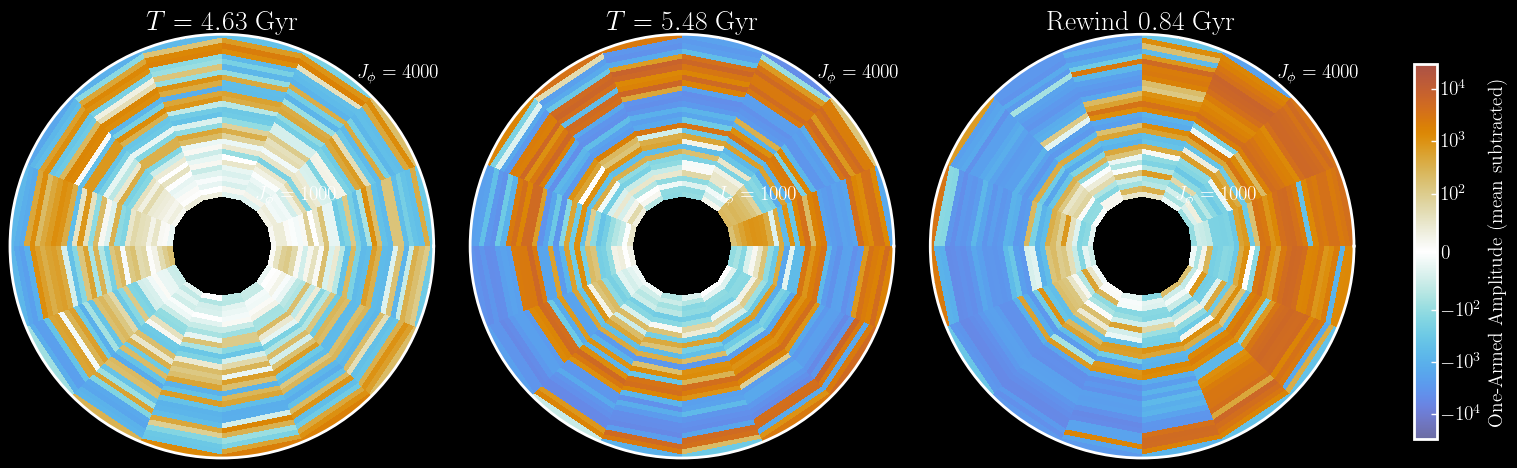

In [12]:
mpl.style.use('dark_background')
plot_rewinding_amp(MSSA0.MakeAnim.pc_rc, 224, 310)

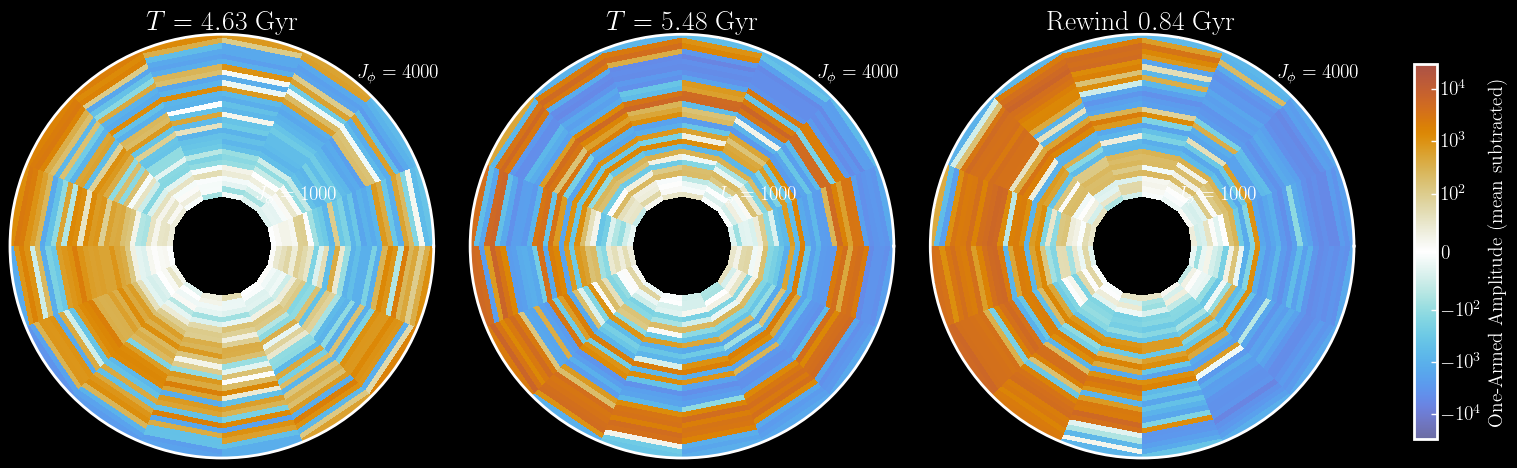

In [14]:
plot_rewinding_amp(MSSA0.MakeAnim.pc_rc, 240, 330)

In [19]:
MSSA0.MakeAnim.reconstruct_from_pcs(pcs=list(range(12,26)))

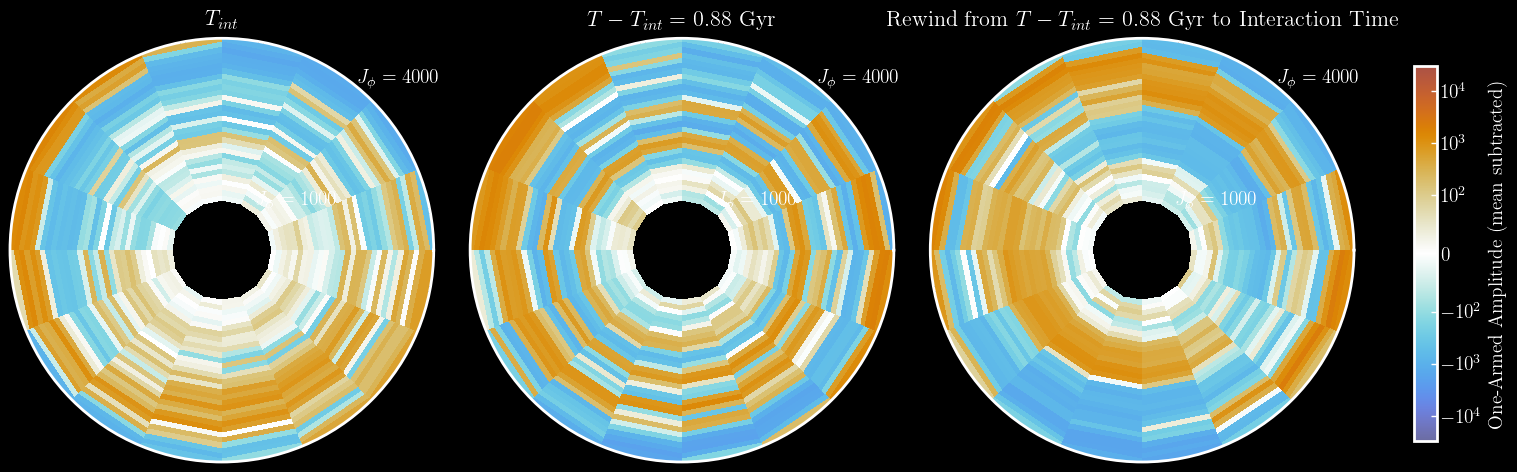

In [22]:
plot_rewinding_amp(MSSA0.MakeAnim.pc_rc, 10, 100)

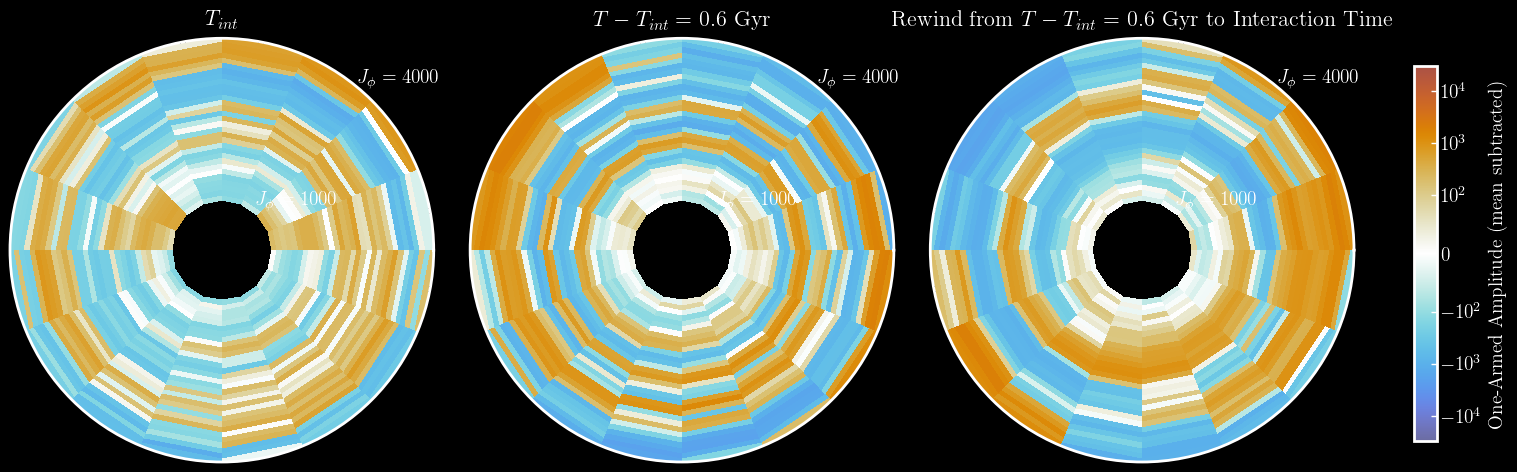

In [23]:
plot_rewinding_amp(MSSA0.MakeAnim.pc_rc, 39, 100)

In [107]:
290*0.009778

2.83562

## First passage m1 amplitude

In [5]:
fig_dir = '../../figures/B2_figures/m1_amp_first_passage/'
data_filename = '../../data/mssa_channels_B2/m1_amp_first_passage_bins_j30_t16.dat'

MSSA = run_mssa.MSSAOperations(data_filename, 'one-armed amplitude', fig_dir)

MSSA.MakeAnim = helper.MakeAnimations(mssa=MSSA.mssa, sim_name='B2', channel_name='m1_amp', 
                                  times=MSSA.times, jphi_min=1000, jbins=31)

figure directory exists - adding to it
---- Eigen is using 4 threads


---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [218]:
MSSA.MakeAnim.reconstruct_from_pcs(pcs=[2,3])

shape U = 52080 x 106
shape Y = 106 x 52080


ignore left plot


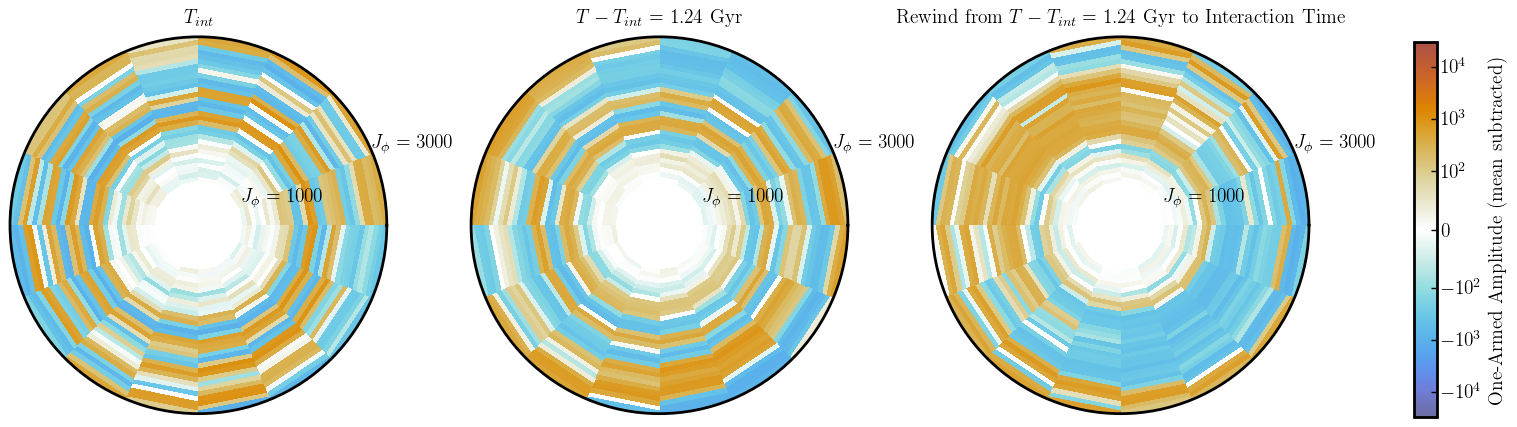

In [227]:
plot_rewinding_comp(MSSA.MakeAnim.pc_rc, -50, 77)

In [87]:
300*ratio

2.9334000000000002

In [6]:
MSSA.MakeAnim.reconstruct_from_pcs(pcs=[4,5])

shape U = 52080 x 106
shape Y = 106 x 52080


ignore left plot


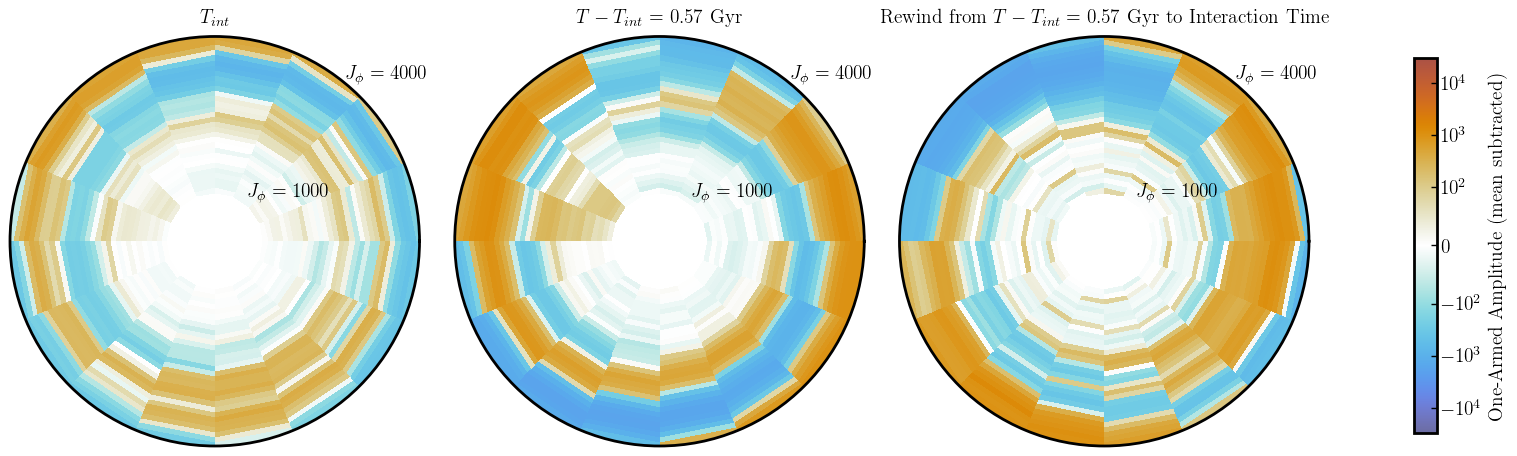

In [11]:
%matplotlib inline
plot_rewinding_amp(MSSA.MakeAnim.pc_rc, -8, 50)

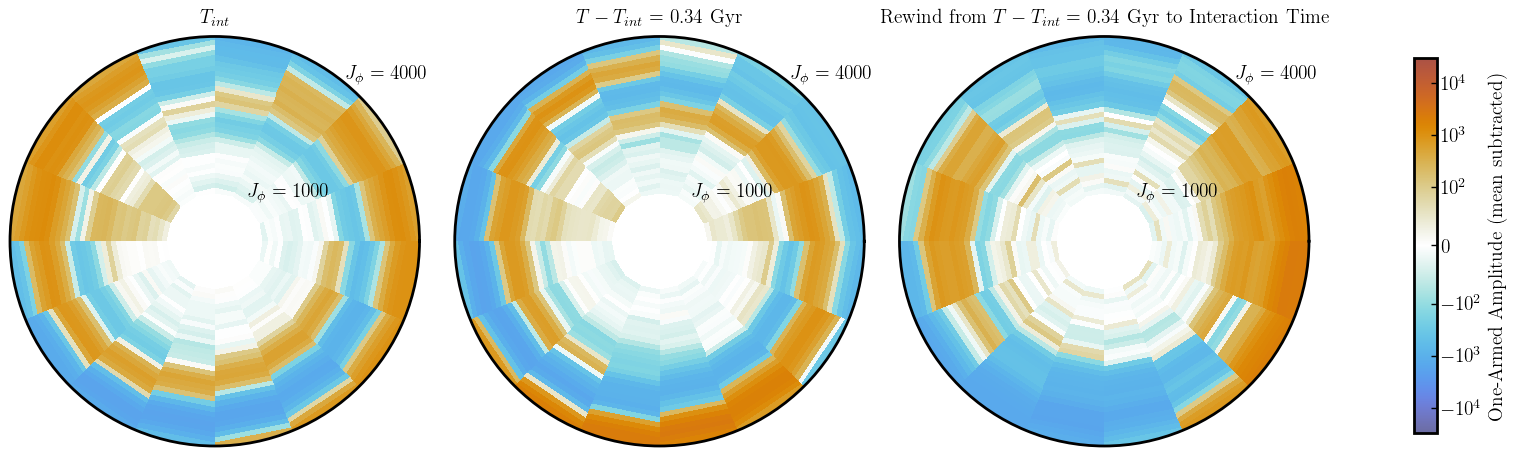

In [17]:
plot_rewinding_amp(MSSA.MakeAnim.pc_rc, 50, 85)

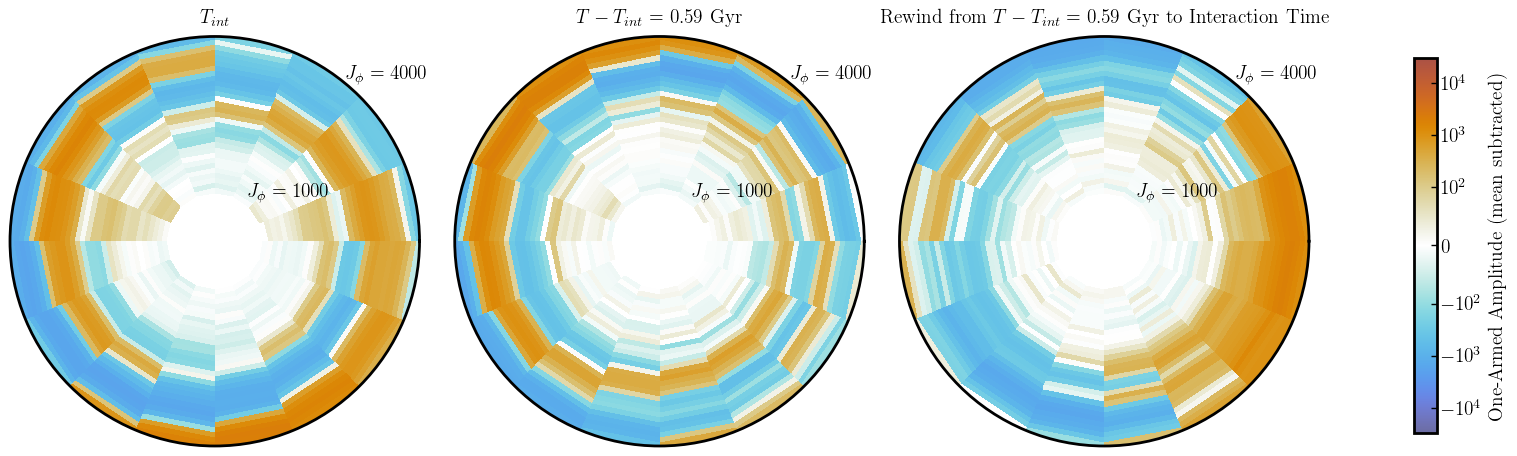

In [18]:
plot_rewinding_amp(MSSA.MakeAnim.pc_rc, 90, 150)

So rewinding from different points gives different dipoles. What if I combine multiple different pc subgroups

In [28]:
MSSA.MakeAnim.reconstruct_from_pcs(pcs=list(range(4,10)))

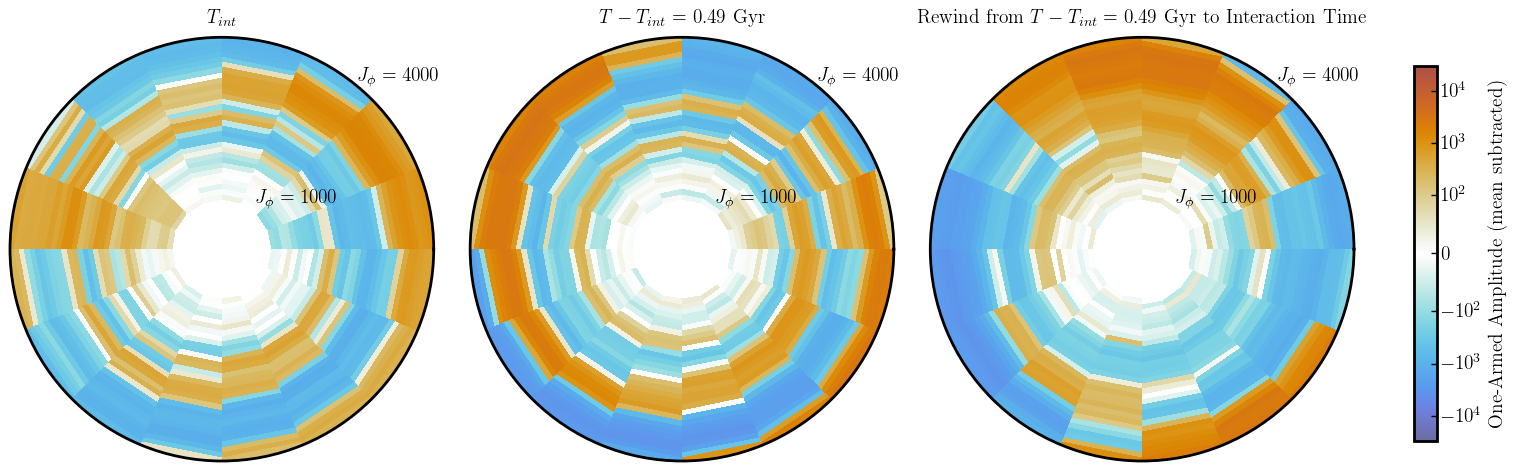

In [33]:
plot_rewinding_amp(MSSA.MakeAnim.pc_rc, 50, 100)

## Second passage m1 amplitude

In [231]:
fig_dir = '../../figures/B2_figures/m1_amp_second_passage/'
data_filename = '../../data/mssa_channels_B2/m1_amp_second_passage_bins_j30_t16.dat'

MSSA = run_mssa.MSSAOperations(data_filename, 'one-armed amplitude', fig_dir)

MSSA.MakeAnim = helper.MakeAnimations(mssa=MSSA.mssa, sim_name='B2', channel_name='m1_amp', 
                                  times=MSSA.times, jphi_min=1000, jbins=31)

figure directory exists - adding to it


---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [232]:
MSSA.MakeAnim.reconstruct_from_pcs(pcs=[0,1])
# these pcs are mostly static so the signal doesn't rotate so should not use to get precise winding time

shape U = 34720 x 71
shape Y = 71 x 34720


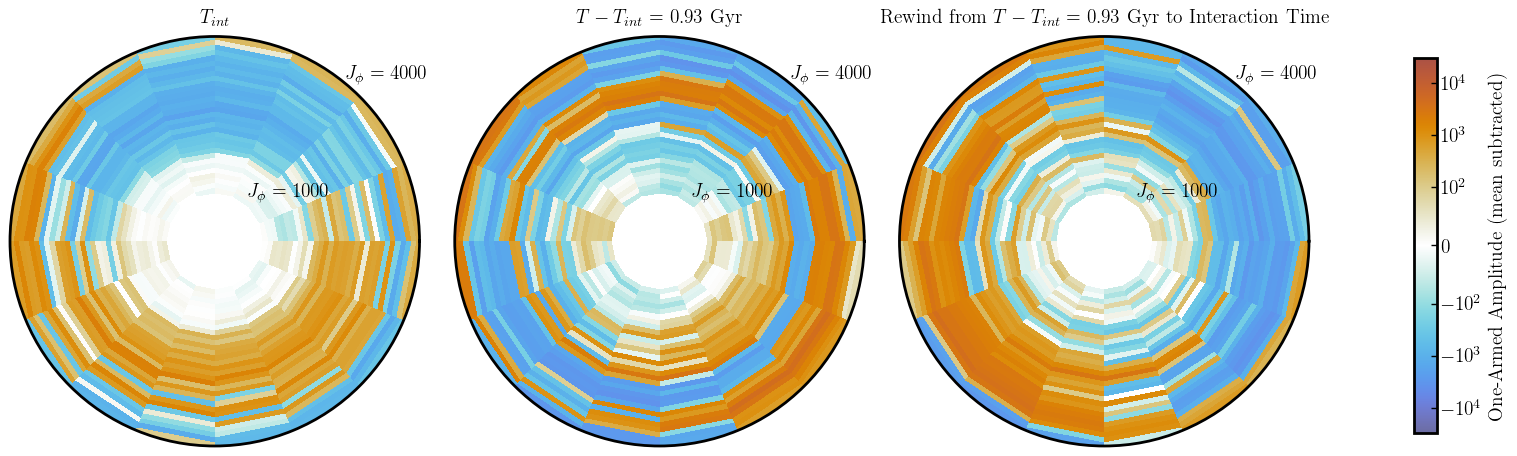

In [235]:
plot_rewinding_comp(MSSA.MakeAnim.pc_rc, 40, 135)

In [163]:
MSSA.MakeAnim.reconstruct_from_pcs(pcs=[2,3])

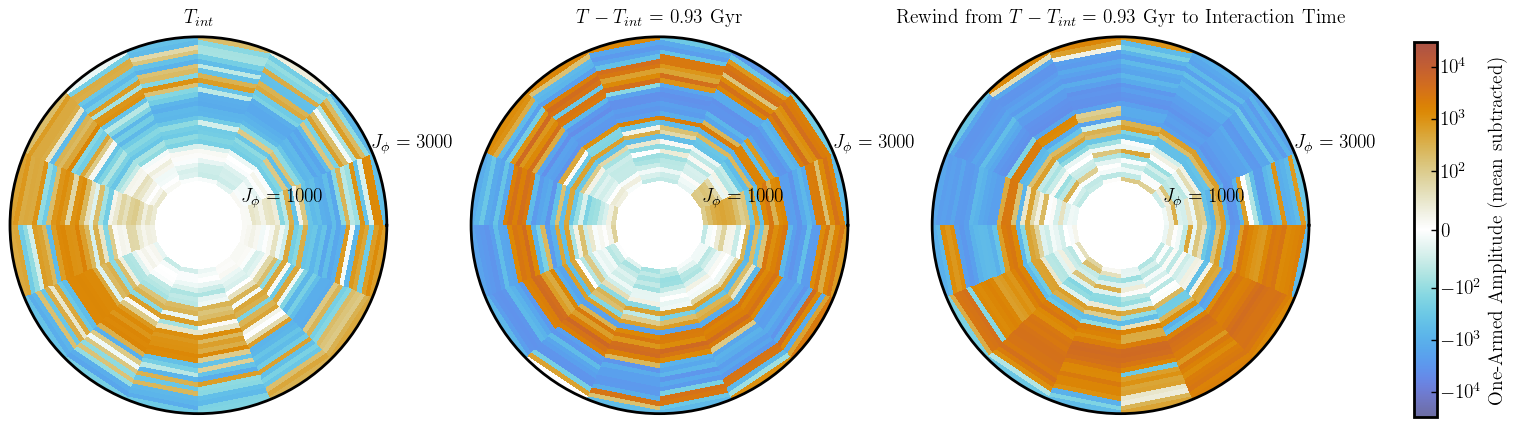

In [181]:
plot_rewinding_comp(MSSA.MakeAnim.pc_rc, 5, 100)

ignore left plot


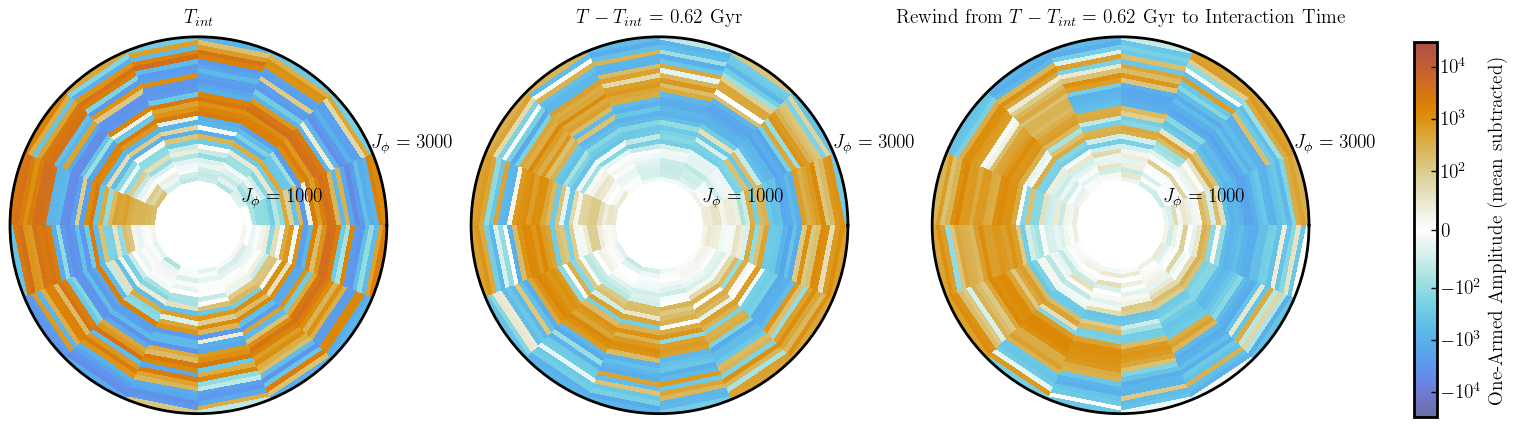

In [195]:
plot_rewinding_comp(MSSA.MakeAnim.pc_rc, -30, 33)

## First passage m1 interaction time

In [268]:
def plot_rewinding_int_time(pc_rc, dipole_timestep, future_timestep):
    vmin = -2 ; vmax = 2 ; linthresh = 0.2
    
    if dipole_timestep < 0: print('ignore left plot')
        
    fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': 'polar'})
    
    pc_rc_dipole_reshape = np.reshape(pc_rc[:,dipole_timestep], T.shape, 'F')
    im1 = ax1.pcolormesh(T, J, pc_rc_dipole_reshape - np.mean(pc_rc_dipole_reshape, axis=0), 
                         cmap=cmr.prinsenvlag_r, rasterized=True,
                         norm=mpl.colors.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax))
    
    
    time_elapsed = (future_timestep - dipole_timestep) * ratio
    d_rot = (time_elapsed * omega_phi)
    
    #now interpolate at each radius so that I can use the same grid as before
    interp = scipy.interpolate.interp1d(tphi_c, pc_rc[:,future_timestep].reshape((jbins, 16)), axis=1, 
                                        fill_value="extrapolate")
    all_interp = interp((T+d_rot)%(2*np.pi))
    future_grid = np.diagonal(all_interp, axis1=0, axis2=2)
    
    pc_rc_future_reshape = np.reshape(pc_rc[:,future_timestep], T.shape, 'F')
    im2 = ax2.pcolormesh(T, J, pc_rc_future_reshape - np.mean(pc_rc_future_reshape, axis=0), 
                         cmap=cmr.prinsenvlag_r, rasterized=True,
                         norm=mpl.colors.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax))
    ax2.set_title(r'$T - T_{int} =$' + ' {} Gyr'.format(round(time_elapsed, 2)), pad=10, fontsize=14)
    
    #plot what that timestep looks like after subtracting background
    im3 = ax3.pcolormesh(T, J, future_grid - np.mean(future_grid, axis=0), cmap=cmr.prinsenvlag_r, rasterized=True,
                         norm=mpl.colors.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax))
    
    
    ax1.set_title(r'$T_{int}$', pad=10, fontsize=14)
    ax3.set_title(r'Rewind from $T - T_{int} =$' + ' {} Gyr to Interaction Time'.format(round(time_elapsed, 2)), pad=10, fontsize=14)
    
    
    
    for ax in [ax1, ax2, ax3]:
        ax.set_yticks([np.min(jphi_c), 2000, 3000, np.max(jphi_c)], labels=[r'$J_\phi=1000$', '', '', r'$J_\phi=4000$'])
        ax.set_rmax(np.max(jphi_c))
        ax.tick_params(left = False, right = False , labelleft = True ,
                             labelbottom = False, bottom = False)      
        # ax.grid(visible=False)
        ax.set_rlabel_position(50)
    
    fig.tight_layout()
    
    
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.95, 0.1, 0.015, 0.75])
    cbar = fig.colorbar(im3, cax=cbar_ax)
    cbar.set_label('One-Armed Interaction Time (mean subtracted)')
    # plt.savefig(fig_dir + 'rewind_m1_amp.pdf')
    plt.show()

In [236]:
fig_dir = '../../figures/B2_figures/m1_int_time_first_passage/'
data_filename = '../../data/mssa_channels_B2/m1_int_time_first_passage_bins_j30_t16.dat'

MSSA = run_mssa.MSSAOperations(data_filename, 'one-armed interaction time', fig_dir)

MSSA.MakeAnim = helper.MakeAnimations(mssa=MSSA.mssa, sim_name='B2', channel_name='m1_int_time', 
                                      times=MSSA.times, jphi_min=1000, jbins=31)

figure directory exists - adding to it


---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [237]:
MSSA.MakeAnim.reconstruct_from_pcs(pcs=list(range(2,28)))

shape U = 52080 x 106
shape Y = 106 x 52080


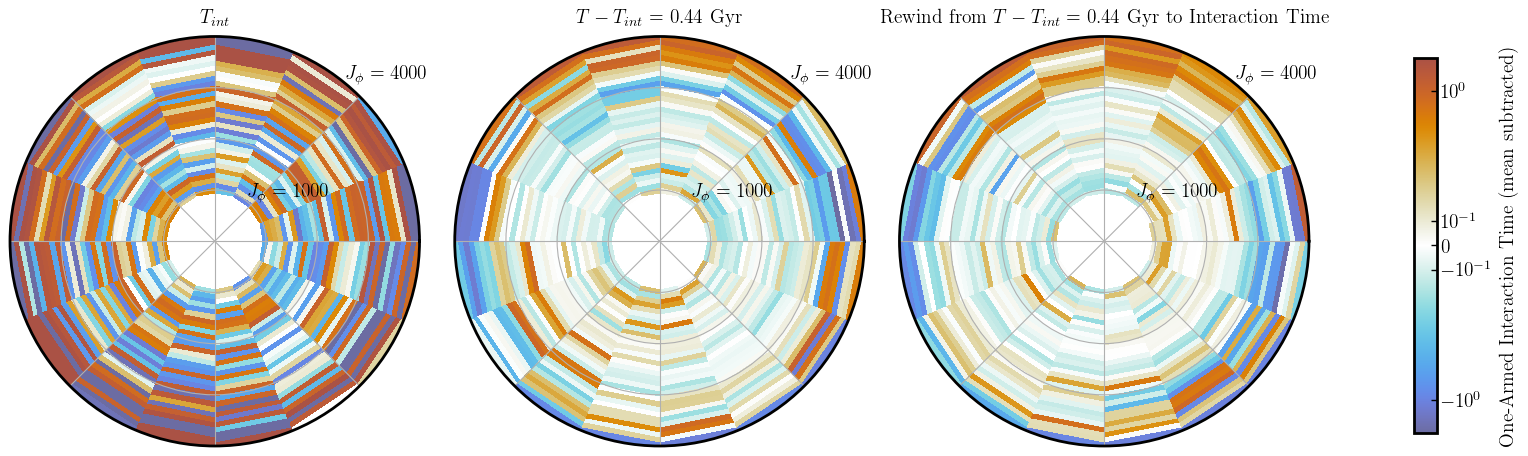

In [264]:
plot_rewinding_int_time(MSSA.MakeAnim.pc_rc, 20, 65)

## Second passage m1 interaction time

In [265]:
fig_dir = '../../figures/B2_figures/m1_int_time_second_passage/'
data_filename = '../../data/mssa_channels_B2/m1_int_time_second_passage_bins_j30_t16.dat'

MSSA = run_mssa.MSSAOperations(data_filename, 'one-armed interaction time', fig_dir)

MSSA.MakeAnim = helper.MakeAnimations(mssa=MSSA.mssa, sim_name='B2', channel_name='m1_int_time', 
                                      times=MSSA.times, jphi_min=1000, jbins=31)

figure directory exists - adding to it


---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [266]:
MSSA.MakeAnim.reconstruct_from_pcs(pcs=list(range(2,4)))

shape U = 34720 x 71
shape Y = 71 x 34720


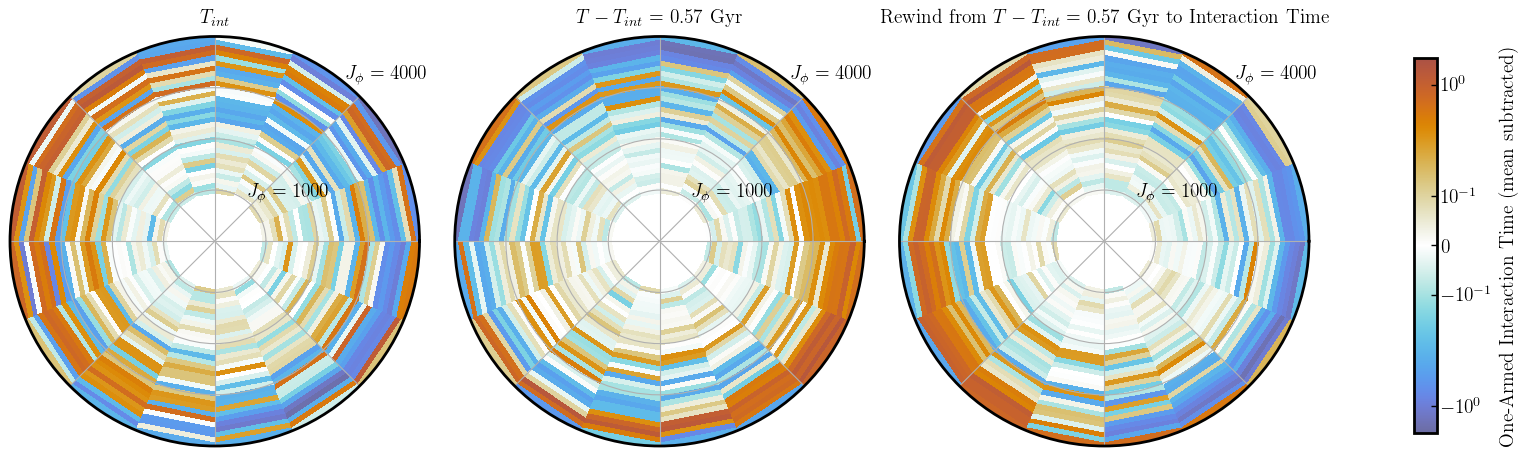

In [282]:
plot_rewinding_int_time(MSSA.MakeAnim.pc_rc, 35, 93)

## First Passage m1 phase

In [283]:
def plot_rewinding_int_time(pc_rc, dipole_timestep, future_timestep):
    vmin = -np.pi ; vmax = np.pi ; linthresh = np.pi/8
    
    if dipole_timestep < 0: print('ignore left plot')
        
    fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': 'polar'})
    
    pc_rc_dipole_reshape = np.reshape(pc_rc[:,dipole_timestep], T.shape, 'F')
    im1 = ax1.pcolormesh(T, J, pc_rc_dipole_reshape - np.mean(pc_rc_dipole_reshape, axis=0), 
                         cmap=cmr.prinsenvlag_r, rasterized=True,
                         norm=mpl.colors.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax))
    
    
    time_elapsed = (future_timestep - dipole_timestep) * ratio
    d_rot = (time_elapsed * omega_phi)
    
    #now interpolate at each radius so that I can use the same grid as before
    interp = scipy.interpolate.interp1d(tphi_c, pc_rc[:,future_timestep].reshape((jbins, 16)), axis=1, 
                                        fill_value="extrapolate")
    all_interp = interp((T+d_rot)%(2*np.pi))
    future_grid = np.diagonal(all_interp, axis1=0, axis2=2)
    
    pc_rc_future_reshape = np.reshape(pc_rc[:,future_timestep], T.shape, 'F')
    im2 = ax2.pcolormesh(T, J, pc_rc_future_reshape - np.mean(pc_rc_future_reshape, axis=0), 
                         cmap=cmr.prinsenvlag_r, rasterized=True,
                         norm=mpl.colors.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax))
    ax2.set_title(r'$T - T_{int} =$' + ' {} Gyr'.format(round(time_elapsed, 2)), pad=10, fontsize=14)
    
    #plot what that timestep looks like after subtracting background
    im3 = ax3.pcolormesh(T, J, future_grid - np.mean(future_grid, axis=0), cmap=cmr.prinsenvlag_r, rasterized=True,
                         norm=mpl.colors.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax))
    
    
    ax1.set_title(r'$T_{int}$', pad=10, fontsize=14)
    ax3.set_title(r'Rewind from $T - T_{int} =$' + ' {} Gyr to Interaction Time'.format(round(time_elapsed, 2)), pad=10, fontsize=14)
    
    
    
    for ax in [ax1, ax2, ax3]:
        ax.set_yticks([np.min(jphi_c), 2000, 3000, np.max(jphi_c)], labels=[r'$J_\phi=1000$', '', '', r'$J_\phi=4000$'])
        ax.set_rmax(np.max(jphi_c))
        ax.tick_params(left = False, right = False , labelleft = True ,
                             labelbottom = False, bottom = False)      
        # ax.grid(visible=False)
        ax.set_rlabel_position(50)
    
    fig.tight_layout()
    
    
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.95, 0.1, 0.015, 0.75])
    cbar = fig.colorbar(im3, cax=cbar_ax)
    cbar.set_label('One-Armed Phase (mean subtracted)')
    # plt.savefig(fig_dir + 'rewind_m1_amp.pdf')
    plt.show()

In [284]:
fig_dir = '../../figures/B2_figures/m1_phase_first_passage/'
data_filename = '../../data/mssa_channels_B2/m1_phase_first_passage_bins_j30_t16.dat'

MSSA = run_mssa.MSSAOperations(data_filename, 'one-armed phase', fig_dir)

MSSA.MakeAnim = helper.MakeAnimations(mssa=MSSA.mssa, sim_name='B2', channel_name='m1_phase', 
                                      times=MSSA.times, jphi_min=1000, jbins=31)

figure directory exists - adding to it


---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [285]:
MSSA.MakeAnim.reconstruct_from_pcs(pcs=list(range(0,4)))

shape U = 52080 x 106
shape Y = 106 x 52080


ignore left plot


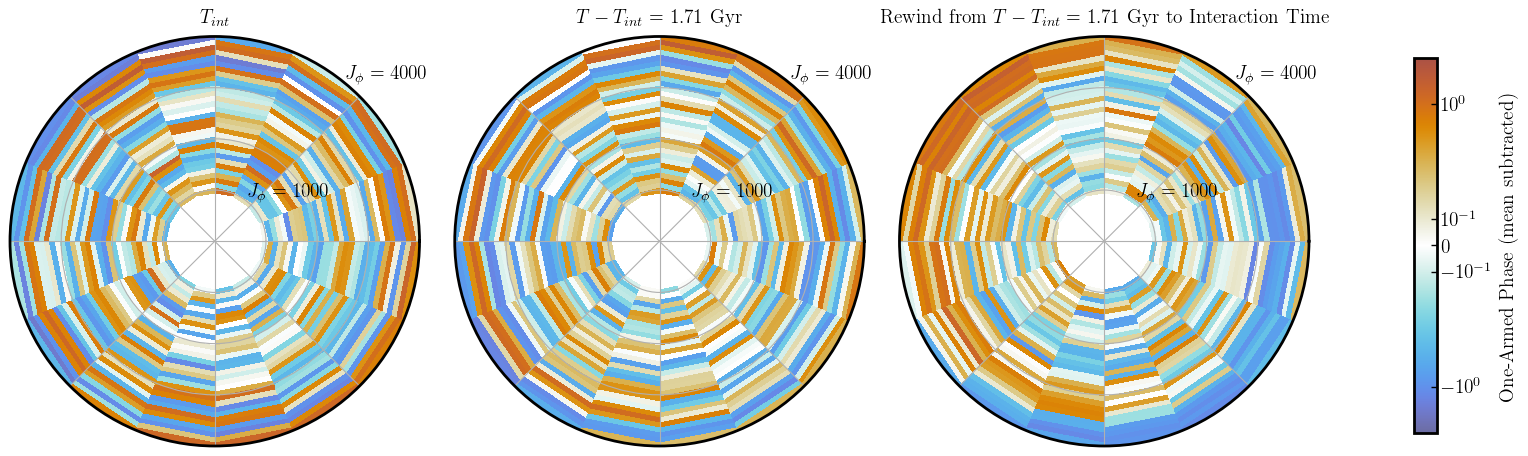

In [290]:
plot_rewinding_int_time(MSSA.MakeAnim.pc_rc, -100, 75)